# K-Nearest Neighbors (KNN): conceptos, matematica e implementacion

Este cuaderno presenta KNN para clasificacion supervisada.

Objetivos:
- Entender la intuicion del algoritmo.
- Revisar la formulacion matematica minima.
- Implementar KNN con `scikit-learn` y una version simple desde cero.
- Evaluar el impacto de `k` y del escalado de variables.


## Dataset publico ampliamente usado: Iris

Usaremos el conjunto **Iris** (Fisher, 1936), disponible publicamente y ampliamente utilizado para introduccion a clasificacion.

- Publico en UCI: https://archive.ics.uci.edu/dataset/53/iris
- Disponible en scikit-learn como `load_iris`.

El dataset contiene 150 flores, 4 variables numericas y 3 clases (`setosa`, `versicolor`, `virginica`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print("Forma del dataset:", df.shape)
print("\nClases:")
print(df["species"].value_counts())


Forma del dataset: (150, 6)

Clases:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 1. Conceptos clave de KNN

KNN es un algoritmo:
- **Supervisado**: aprende a partir de ejemplos etiquetados.
- **No parametrico**: no ajusta una ecuacion global explicita como regresion lineal.
- **Lazy learner**: durante entrenamiento basicamente almacena los datos.

Para clasificar un nuevo punto, KNN busca los `k` vecinos mas cercanos y asigna la clase mas frecuente (o mas "pesada" por distancia).


## 2. Matematica minima

Sea un conjunto de entrenamiento `D = {(x_i, y_i)}_{i=1}^n`, con `x_i` en `R^d`.

### Distancia de Minkowski

$$
d_p(x, z) = \left(\sum_{j=1}^{d} |x_j - z_j|^p\right)^{1/p}
$$

Explicacion simple (pregrado):
- Esta formula mide que tan diferentes son dos observaciones `x` y `z`.
- Compara variable por variable, suma esas diferencias y devuelve una sola distancia.
- Si la distancia es pequena, los puntos son parecidos; si es grande, son distintos.

Casos frecuentes:
- `p = 1`: Manhattan
- `p = 2`: Euclidiana

Referencia de la ecuacion: Deza, M. M., & Deza, E. (2009). *Encyclopedia of Distances*. Springer.

### Regla de decision (clasificacion)

$$
\hat{y}(x^*) = \arg\max_{c} \sum_{i \in N_k(x^*)} w_i\,\mathbb{1}(y_i=c)
$$

Explicacion simple (pregrado):
- `x*` es el nuevo dato que queremos clasificar.
- Buscamos sus `k` vecinos mas cercanos.
- Cada vecino vota por su clase.
- La clase con mas votos (o mas peso) es la prediccion final.
- `\mathbb{1}(y_i=c)` vale 1 cuando el vecino `i` pertenece a la clase `c`, y 0 en otro caso.

Donde:
- `N_k(x*)` es el conjunto de los `k` vecinos mas cercanos.
- `w_i` son pesos opcionales.
- Si no hay pesos, `w_i = 1`.
- Con pesos por distancia, una opcion comun es `w_i = 1 / (d(x^*, x_i) + eps)`.

Referencias de la regla de decision:
- Cover, T., & Hart, P. (1967). Nearest Neighbor Pattern Classification. *IEEE Transactions on Information Theory*, 13(1), 21-27.
- Dudani, S. A. (1976). The Distance-Weighted k-Nearest-Neighbor Rule. *IEEE Transactions on Systems, Man, and Cybernetics*, SMC-6(4), 325-327.

### Nota practica
KNN depende de distancias, por lo que **escalar variables** suele ser necesario.


## 3. Preparacion de datos

Separaremos entrenamiento y prueba con estratificacion y aplicaremos `StandardScaler`.


In [4]:
X = df[iris.feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape, "| X_test:", X_test_scaled.shape)


X_train: (105, 4) | X_test: (45, 4)


## 4. Implementacion con scikit-learn

Evaluaremos varios valores de `k` y compararemos dos estrategias de voto:
- `weights='uniform'`: todos los vecinos votan igual.
- `weights='distance'`: vecinos cercanos pesan mas.


In [5]:
resultados = []

for k in range(1, 26):
    for w in ["uniform", "distance"]:
        model = KNeighborsClassifier(n_neighbors=k, weights=w, metric="minkowski", p=2)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

        resultados.append(
            {
                "k": k,
                "weights": w,
                "accuracy": accuracy_score(y_test, pred),
                "f1_macro": f1_score(y_test, pred, average="macro")
            }
        )

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(["f1_macro", "accuracy"], ascending=False).head(10)


,k,weights,accuracy,f1_macro
15,8,distance,0.955556,0.955357
16,9,uniform,0.955556,0.955357
19,10,distance,0.955556,0.955357
20,11,uniform,0.955556,0.955357
22,12,uniform,0.955556,0.955357
23,12,distance,0.955556,0.955357
26,14,uniform,0.955556,0.955357
27,14,distance,0.955556,0.955357
24,13,uniform,0.933333,0.933259
28,15,uniform,0.933333,0.933259


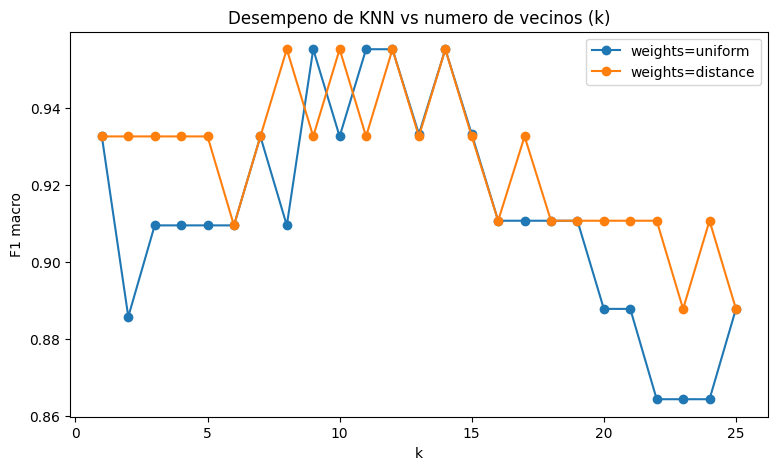

In [6]:
plt.figure(figsize=(9, 5))
for w in ["uniform", "distance"]:
    subset = df_resultados[df_resultados["weights"] == w]
    plt.plot(subset["k"], subset["f1_macro"], marker="o", label=f"weights={w}")
plt.legend()
plt.title("Desempeno de KNN vs numero de vecinos (k)")
plt.ylabel("F1 macro")
plt.xlabel("k")
plt.show()


In [7]:
mejor_fila = df_resultados.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
best_k = int(mejor_fila["k"])
best_weights = mejor_fila["weights"]

print("Mejor configuracion:")
print(f"k = {best_k}, weights = {best_weights}, f1_macro = {mejor_fila['f1_macro']:.4f}")


Mejor configuracion:
k = 8, weights = distance, f1_macro = 0.9554


## 5. Evaluacion del mejor modelo


In [8]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, weights=best_weights, metric="minkowski", p=2)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



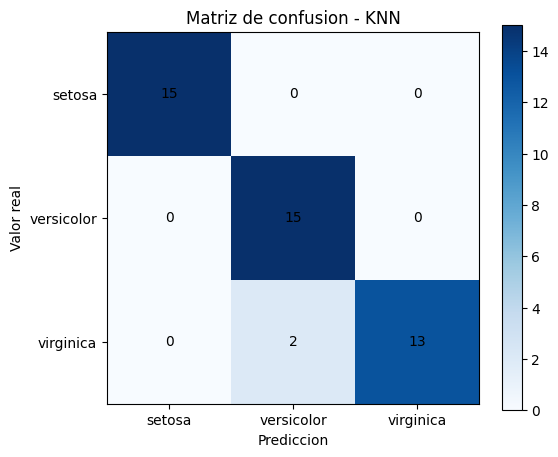

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
plt.xticks(range(len(iris.target_names)), iris.target_names)
plt.yticks(range(len(iris.target_names)), iris.target_names)
plt.colorbar()
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.title("Matriz de confusion - KNN")
plt.show()


## 6. Implementacion simple de KNN desde cero (didactica)

La siguiente version busca transparencia conceptual. No esta optimizada para grandes volumenes.


In [10]:
def minkowski_distance(x, z, p=2):
    return np.sum(np.abs(x - z) ** p) ** (1.0 / p)


def knn_predict_one(x_query, X_train, y_train, k=5, p=2, weighted=False, eps=1e-9):
    distances = np.array([minkowski_distance(x_query, x_i, p=p) for x_i in X_train])
    idx_sorted = np.argsort(distances)[:k]

    y_neighbors = y_train[idx_sorted]
    d_neighbors = distances[idx_sorted]

    classes = np.unique(y_train)
    votos = {c: 0.0 for c in classes}

    for cls, dist in zip(y_neighbors, d_neighbors):
        weight = 1.0 if not weighted else 1.0 / (dist + eps)
        votos[cls] += weight

    return max(votos, key=votos.get)


def knn_predict_batch(X_query, X_train, y_train, k=5, p=2, weighted=False):
    return np.array([
        knn_predict_one(x, X_train, y_train, k=k, p=p, weighted=weighted)
        for x in X_query
    ])


In [11]:
y_pred_scratch = knn_predict_batch(
    X_test_scaled,
    X_train_scaled,
    y_train,
    k=best_k,
    p=2,
    weighted=(best_weights == "distance")
)

acc_scratch = accuracy_score(y_test, y_pred_scratch)
f1_scratch = f1_score(y_test, y_pred_scratch, average="macro")

print(f"Accuracy scratch: {acc_scratch:.4f}")
print(f"F1 macro scratch: {f1_scratch:.4f}")
print("Coincidencia con scikit-learn:", np.mean(y_pred_scratch == y_pred))


Accuracy scratch: 0.9556
F1 macro scratch: 0.9554
Coincidencia con scikit-learn: 1.0


## 7. Efecto de no escalar variables

Compararemos con un KNN equivalente pero sin `StandardScaler` para ilustrar por que el preprocesamiento importa.


In [12]:
knn_no_scale = KNeighborsClassifier(n_neighbors=best_k, weights=best_weights)
knn_no_scale.fit(X_train, y_train)
pred_no_scale = knn_no_scale.predict(X_test)

print("F1 macro sin escalar:", round(f1_score(y_test, pred_no_scale, average="macro"), 4))
print("F1 macro con escalado:", round(f1_score(y_test, y_pred, average="macro"), 4))


F1 macro sin escalar: 0.9327
F1 macro con escalado: 0.9554


## 8. Conclusiones

1. KNN clasifica por proximidad local, no por una frontera global aprendida de forma explicita.
2. `k` controla el sesgo-varianza: valores pequenos pueden sobreajustar, valores grandes suavizan demasiado.
3. El escalado de variables es critico cuando las magnitudes de las features son diferentes.
4. `weights='distance'` puede mejorar resultados cuando vecinos muy cercanos contienen informacion mas relevante.
